In [7]:
%load_ext autoreload
%autoreload 2
import os
import pandas as pd
import matplotlib.pyplot as plt

# IEEE/Applied Energy Double-Column Formatting Standard
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 300
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
# Anchor to the project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

from src.config import SimConfig, EnvConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.utils.plotting import plot_simulation_dashboard, plot_benchmarker_results
from src.solvers import AugmentedHybridSDPSolver
from src.plants import AugmentedHybridPlant
from src.controllers import build_approach, AugmentedFCLockedControl, AugmentedPolicyControl, AugmentedValueControl

In [9]:
# 1. Setup the Environment and Lock the High-Fidelity Physics
env = EnvConfig()

# We use the highest acceptable fidelity for the baseline showdown
config = SimConfig(
    dP=90.0, 
    Dt=180,                  
    N_Pd=5,  # Capped at 5 to ensure dense Markov matrices 
    n_pack=1, # 12 Individual modules (Max Fidelity)
    alpha_fc=4
)

fleet_data = load_and_cache_entire_fleet(env)
exclude_days = [1, 2, 3] 
benchmarker = VoyageBenchmarker(fleet_data, env, config, exclude_days)


⚙️  EMS Configuration Loaded | Smart Grid: ON
 -> dP Step Size       : 90.0 kW
 -> Grid Dimensions    : N_d=5, N_n=13, N_soc=67, N_fc=28, N_bat=24
 -> Augmented Space |S|: 121,940 states
 -> Action Space |A|   : 312 actions
 -> Time steps   : 480 steps/day
 -> Est. Big-O Comput. : O(18,554,390,400) operations / day
 -> Est. RAM Footprint : ~1118.72 MB

Loading fleet data from binary cache (fleet_data_cache_scale_0.75.npz)...
 -> Cache instantly loaded in 0.090 seconds.


In [10]:
# 2. Define the Control Architectures (Testing continuous 1Hz tracking)
approaches = {
    "PLC (FCLocked)": build_approach(
        controller_cls=AugmentedFCLockedControl, 
        plant_cls=AugmentedHybridPlant, 
        solver_cls=AugmentedHybridSDPSolver, 
        is_macro=False
    ),
    "Interpolated (Policy)": build_approach(
        controller_cls=AugmentedPolicyControl, 
        plant_cls=AugmentedHybridPlant, 
        solver_cls=AugmentedHybridSDPSolver, 
        is_macro=False
    ),
    "Lookahead (Value)": build_approach(
        controller_cls=AugmentedValueControl, 
        plant_cls=AugmentedHybridPlant, 
        solver_cls=AugmentedHybridSDPSolver, 
        is_macro=False
    ),
}

In [11]:
# 3. Run the Benchmarks
print("--- RUNNING ARCHITECTURE SHOWDOWN (LOOCV) ---")
reports = {}

for app_name, factory in approaches.items():
    print(f"\nEvaluating {app_name}...")
    reports[app_name] = benchmarker.run_leave_one_out(factory)

summary_rows = {name: rep.summary.loc['Average'] for name, rep in reports.items()}
master_summary = pd.DataFrame(summary_rows).T

print("\n--- MASTER PERFORMANCE SUMMARY ---")
print_markdown_table(master_summary)

--- RUNNING ARCHITECTURE SHOWDOWN (LOOCV) ---



Evaluating PLC (FCLocked)...
 [Vault] Cache MISS: Training Markov Chain for days [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 6, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 7, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 8, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 9, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 10, 11, 12, 13, 14]
 [Vault] Cache MISS: Solving SDP(AugmentedHybridSDPSolver)
 [Vault] Cache MISS: Training Markov Chain for days [4, 5, 6, 7, 8, 9, 11, 12, 13, 14]


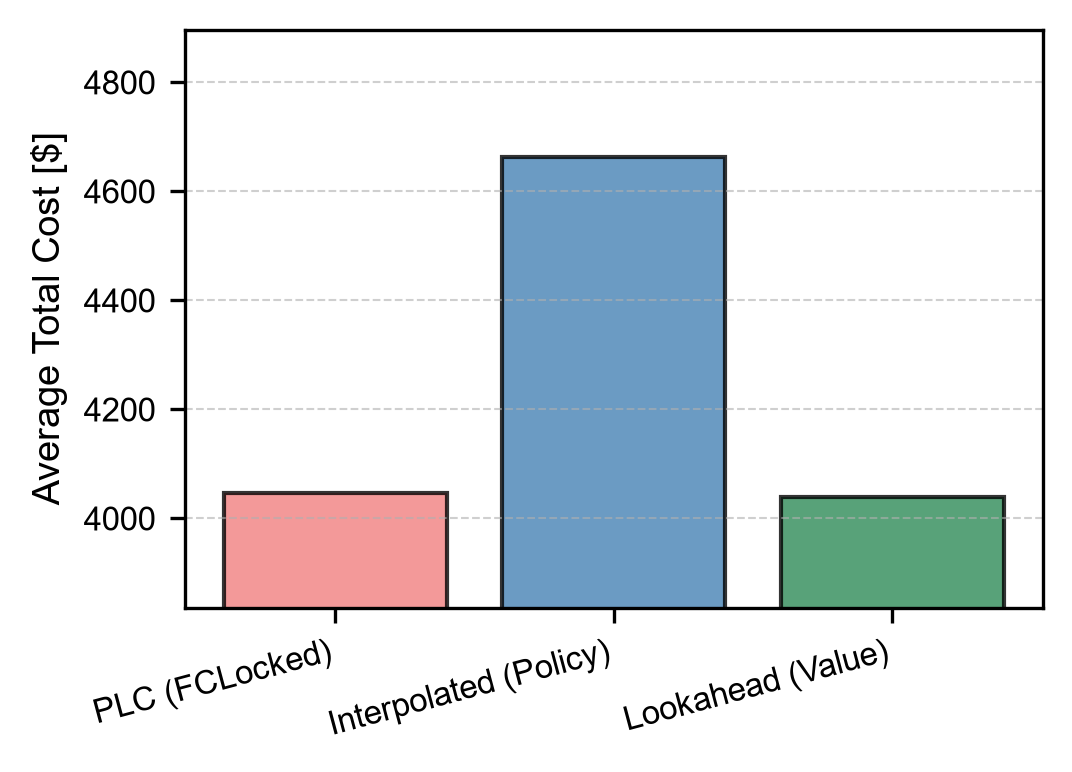


--- GENERATING 2-COLUMN DASHBOARDS FOR DAY 9 ---


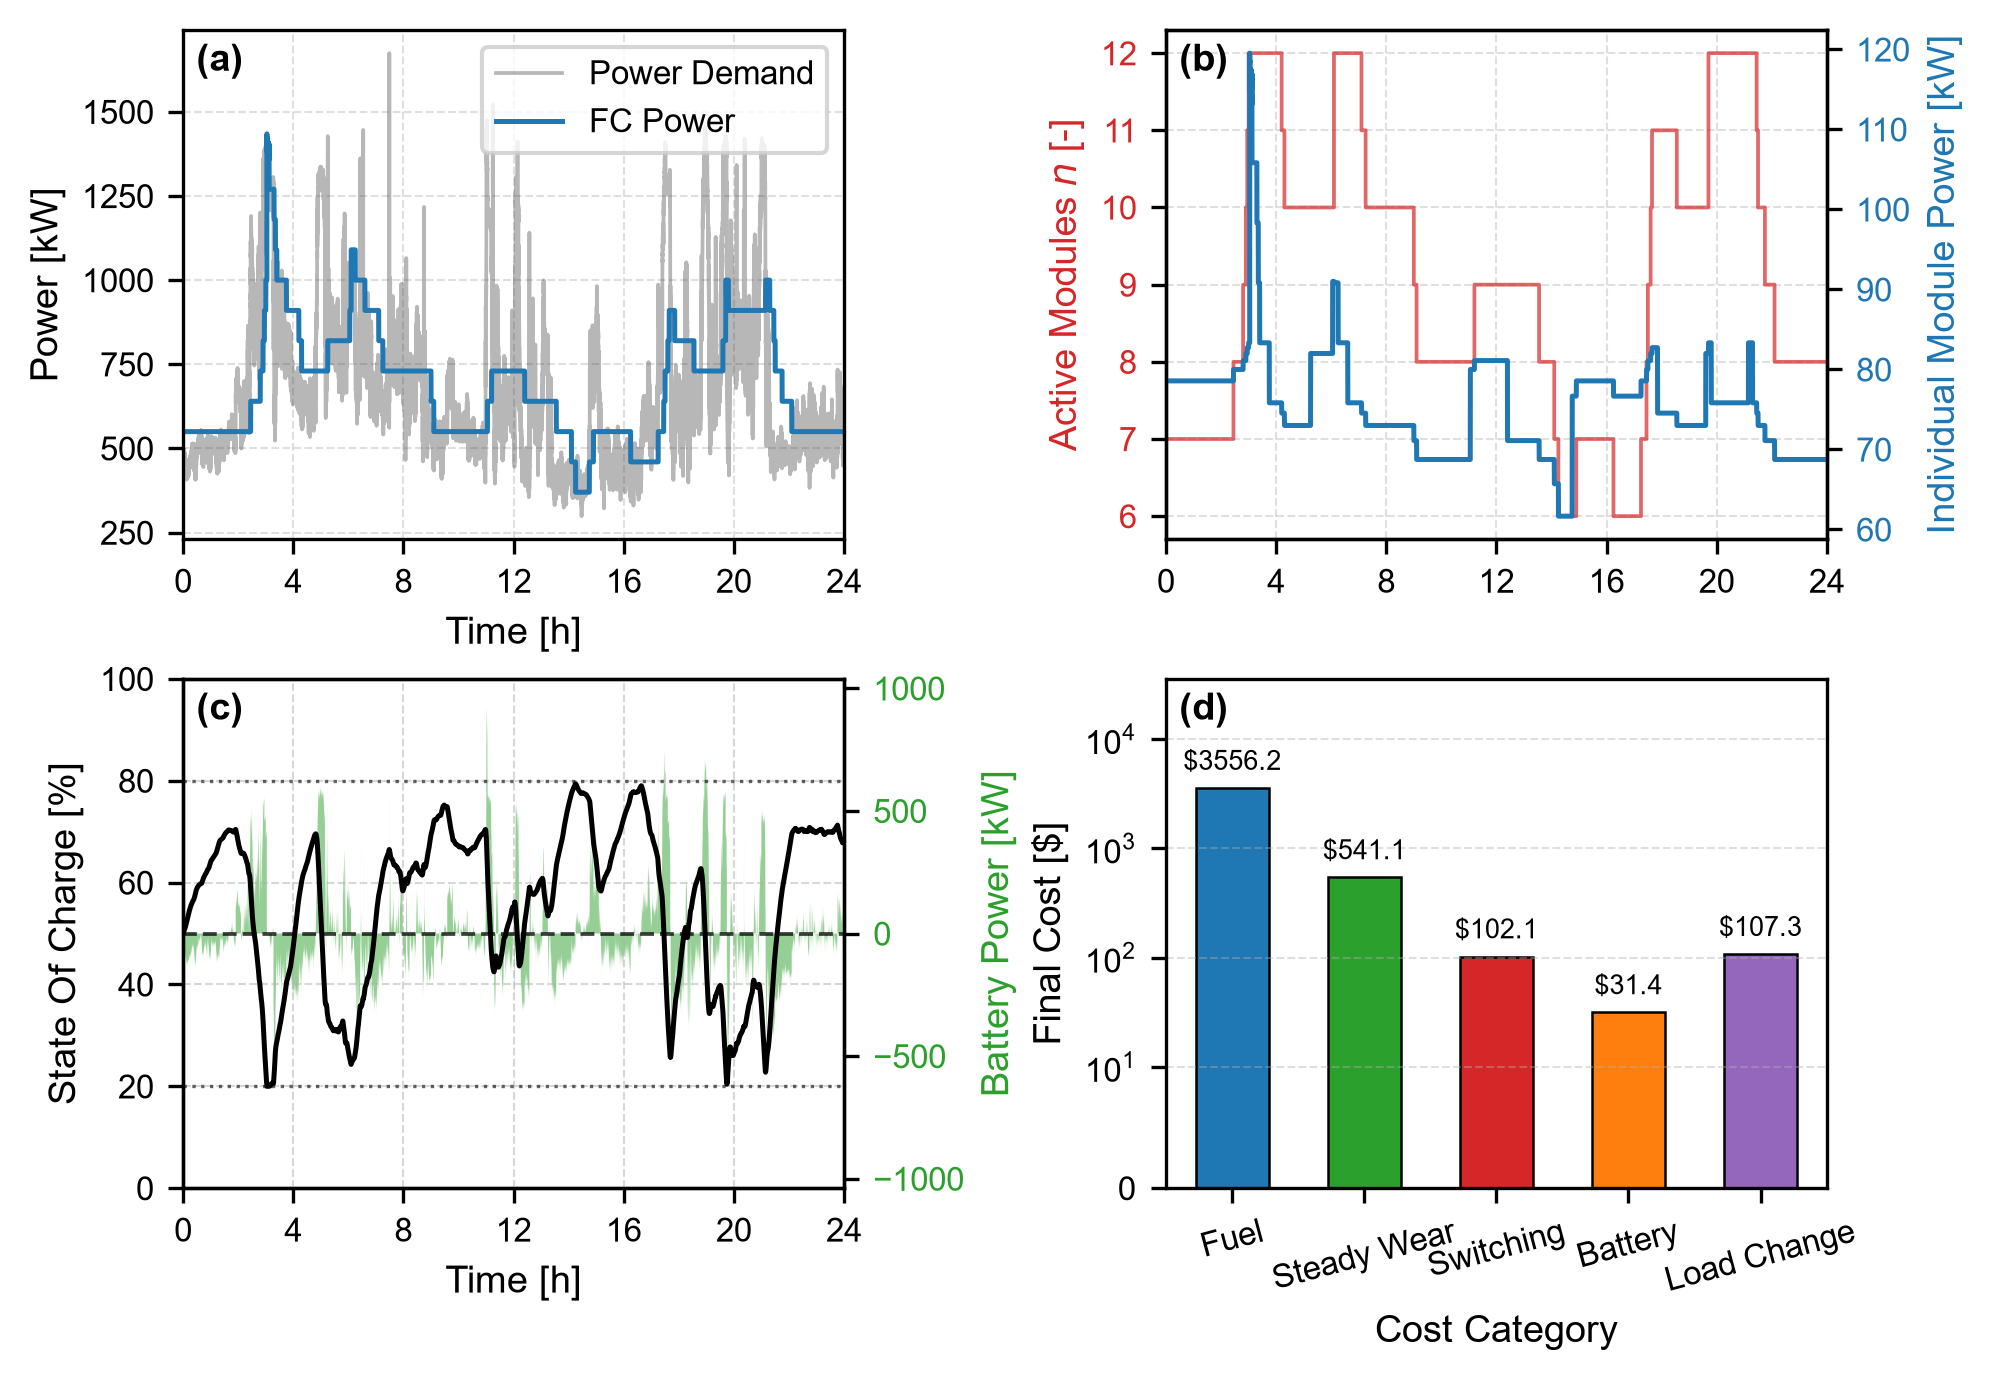

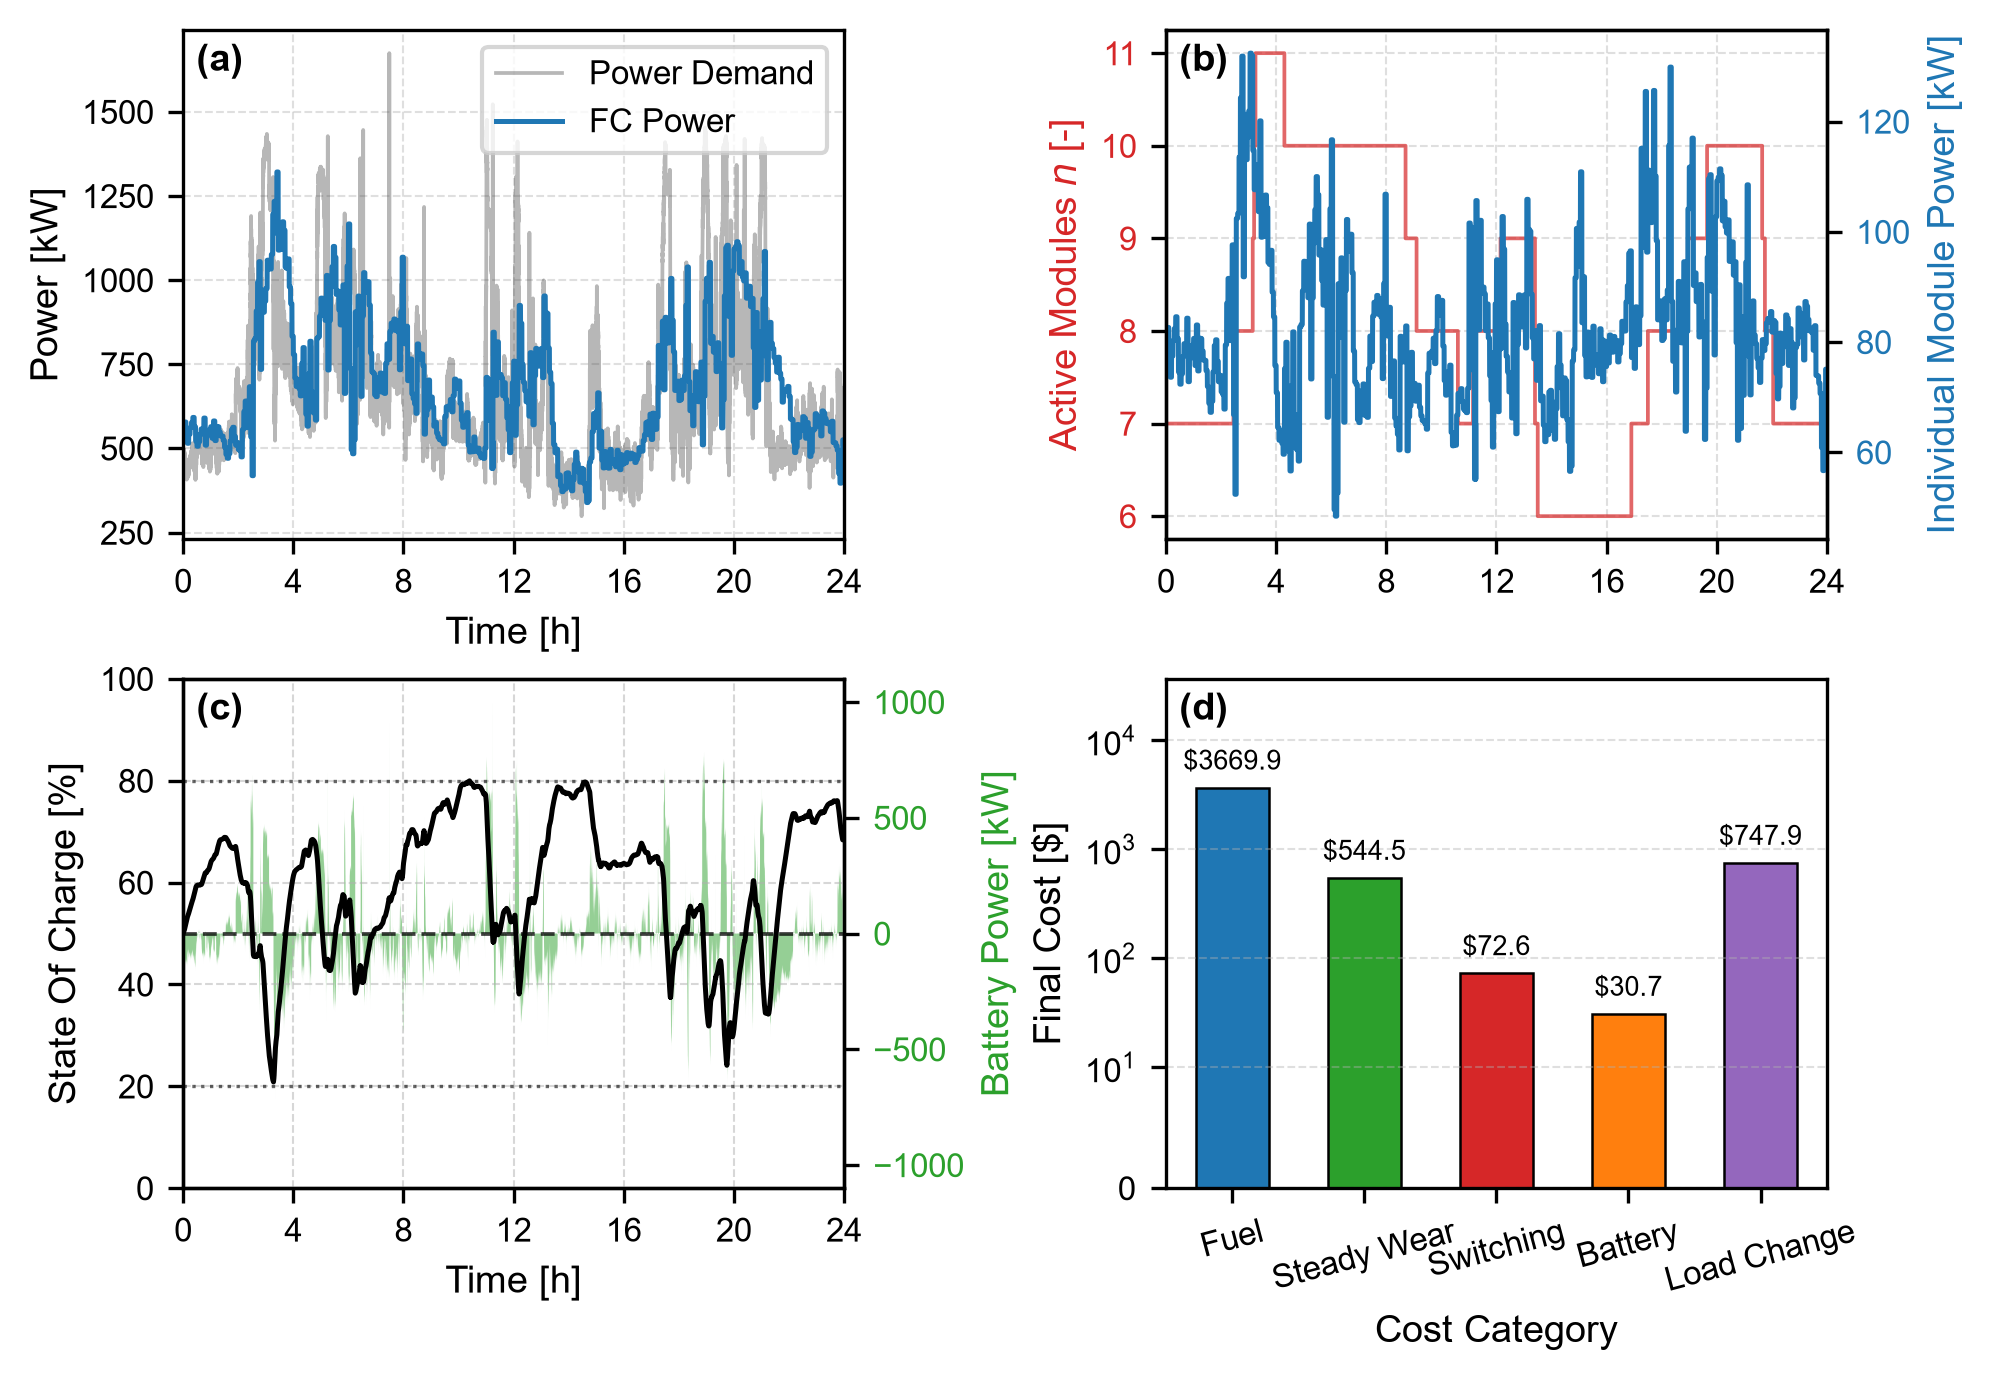

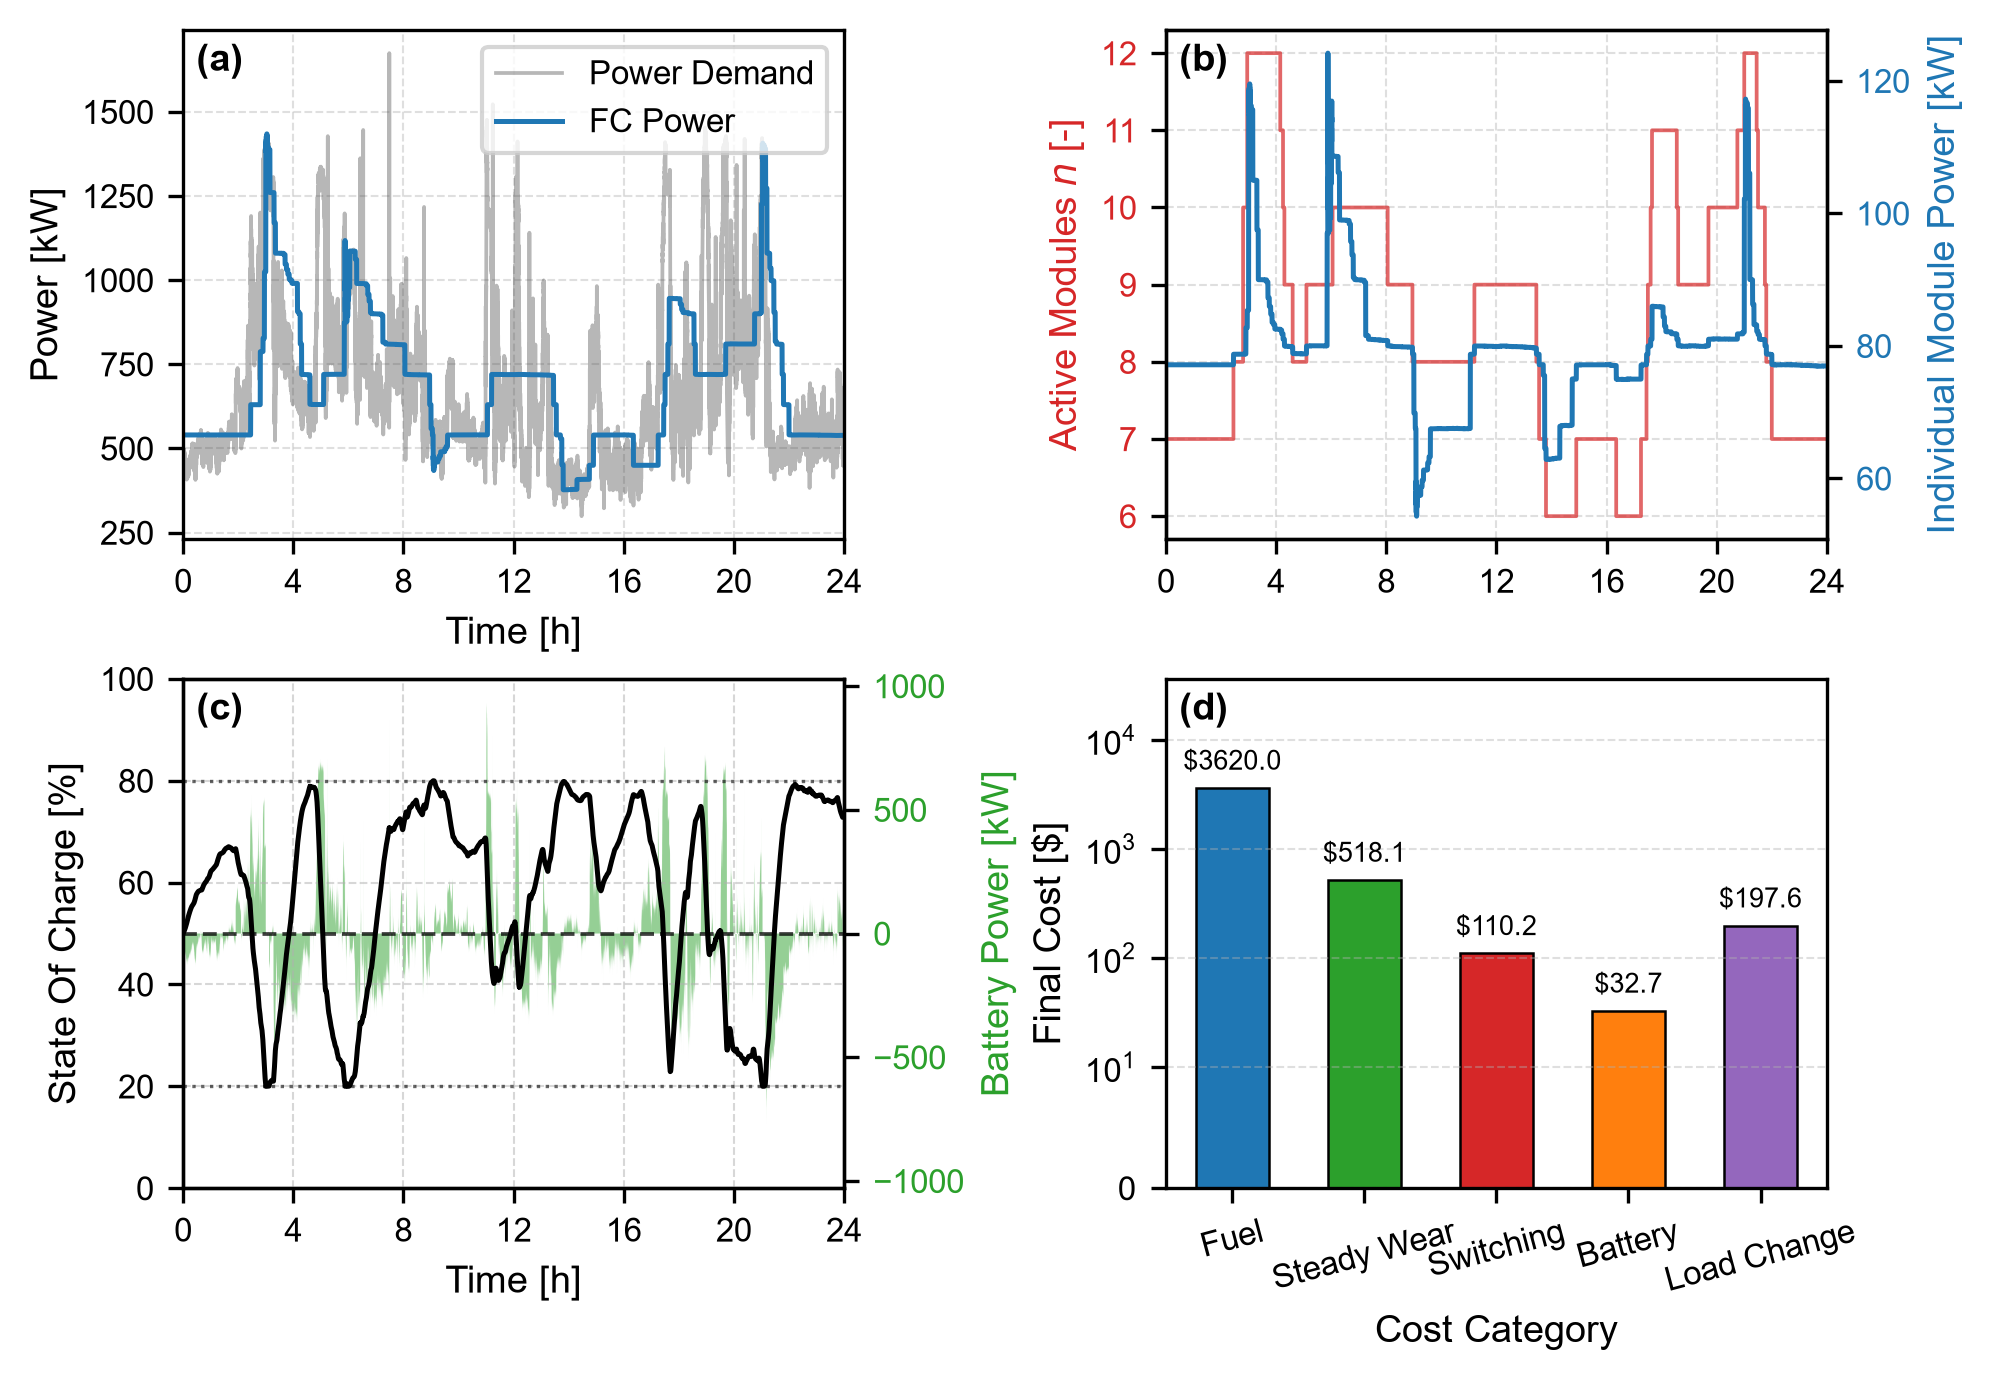

In [16]:
# 4. Generate Publication-Ready Figures
os.makedirs('figures', exist_ok=True)

# Plot 1: Architecture Showdown Bar Chart (Single Column Width: 3.5 inches)
fig, ax = plt.subplots(figsize=(3.5, 2.5))

costs = master_summary['Total Cost [$]']
bars = ax.bar(costs.index, costs.values, color=['lightcoral', 'steelblue', 'seagreen'], edgecolor='black', alpha=0.8)

ax.set_ylabel("Average Total Cost [$]")
ax.set_ylim([costs.min() * 0.95, costs.max() * 1.05]) # Zoom in to highlight the difference
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.xticks(rotation=15, ha='right')
plt.tight_layout(pad=0.5)
plt.savefig('figures/01_architecture_showdown.png')
plt.show()

# Plot 2: Dashboard for Day 9 to show the physics (Double Column Width: 7.16 inches)
test_day = 9
run_id = f"Day {test_day}"
print(f"\n--- GENERATING 2-COLUMN DASHBOARDS FOR DAY {test_day} ---")

for app_name in approaches.keys():
    df_telemetry = reports[app_name].get_telemetry(run_id)
    # Note: Inside plot_simulation_dashboard, ensure figsize=(7.16, X) is used if possible
    plot_simulation_dashboard(
        df_telemetry, 
        config, 
        title=f"Day {test_day}: {app_name}", 
        indiv=False,
        save_plot=False
    )